In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import random

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Opening the file.

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
file_path = '/content/drive/MyDrive/data.h5'

def inspect_h5(file_path):
    with h5py.File(file_path, 'r') as f:
        print("Structure of the file")
        print("Keys", list(f.keys()))

        def print_structure(name, obj):
            if isinstance(obj, h5py.Dataset):
                print(f"Dataset: {name} | Shape: {obj.shape} | Dtype: {obj.dtype}")

        print("\n Dataset details")
        f.visititems(print_structure)

inspect_h5(file_path)

Structure of the file
Keys ['battery_typ', 'image']

 Dataset details
Dataset: battery_typ | Shape: (4395,) | Dtype: |S18
Dataset: image | Shape: (4395, 1, 256, 256) | Dtype: float32


Creating class that reads the data and converts to integers. Converts also to torch tensors.

In [ ]:
label_map = {
    'cylindrical': 0,
    'pouch': 1,
    'prismatic': 2
}

class BatteryDataset(Dataset):
    def __init__(self, h5_file):
        with h5py.File(h5_file, 'r') as f:
            raw_images = f['image'][:]
            raw_labels = f['battery_typ'][:]

        decoded_labels = [label.decode('utf-8').strip() for label in raw_labels]
        self.labels = [label_map[lbl] for lbl in decoded_labels]

        self.images = torch.tensor(raw_images, dtype=torch.float32)
        self.labels = torch.tensor(self.labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

dataset = BatteryDataset(file_path)

Spliting data among train (70%), val(15%) and test(15%).
Creation of DataLoaders.

In [ ]:
from torch.utils.data import Subset, DataLoader
from sklearn.model_selection import train_test_split

all_labels = dataset.labels
indices = np.arange(len(dataset))

train_idx, temp_idx, train_labels, temp_labels = train_test_split(
    indices,
    all_labels,
    test_size=0.30,
    random_state=42,
    stratify=all_labels
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
)

train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)
test_dataset = Subset(dataset, test_idx)

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train-data quantity: {len(train_dataset)}")
print(f"Val-data quantity: {len(val_dataset)}")
print(f"Test-data quantity: {len(test_dataset)}")

Train-data quantity: 3076
Val-data quantity: 659
Test-data quantity: 660


Defining Baseline CNN Arch. (2 convolutional layers)

In [ ]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=3):
        super(BaselineCNN, self).__init__()

        # Conv 1
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Conv 2
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fully Connected
        self.fc1 = nn.Linear(16 * 64 * 64, 64)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))

        x = x.view(x.size(0), -1)  #Flatten
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

model_baseline = BaselineCNN().to(device)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Parameters count: {count_parameters(model_baseline):,}")

Parameters count: 4,195,811


Train and validation loops.

In [ ]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_baseline.parameters(), lr=0.001)

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        epoch_train_loss = running_loss / total_train
        epoch_train_acc = correct_train / total_train

        # Validation
        model.eval()
        val_running_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        epoch_val_loss = val_running_loss / total_val
        epoch_val_acc = correct_val / total_val

        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(epoch_val_acc)

        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc*100:.2f}% | "
              f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc*100:.2f}%")

    return history

baseline_history = train_model(model_baseline, train_loader, val_loader, criterion, optimizer, epochs=10)

Epoch [1/10] | Train Loss: 0.6221 | Train Acc: 77.73% | Val Loss: 0.4973 | Val Acc: 82.40%
Epoch [2/10] | Train Loss: 0.4925 | Train Acc: 84.66% | Val Loss: 0.4635 | Val Acc: 86.95%
Epoch [3/10] | Train Loss: 0.4609 | Train Acc: 85.96% | Val Loss: 0.4390 | Val Acc: 87.25%
Epoch [4/10] | Train Loss: 0.4438 | Train Acc: 86.93% | Val Loss: 0.4216 | Val Acc: 88.62%
Epoch [5/10] | Train Loss: 0.4068 | Train Acc: 88.17% | Val Loss: 0.4441 | Val Acc: 87.71%
Epoch [6/10] | Train Loss: 0.3869 | Train Acc: 89.14% | Val Loss: 0.4095 | Val Acc: 88.77%
Epoch [7/10] | Train Loss: 0.3837 | Train Acc: 88.91% | Val Loss: 0.3904 | Val Acc: 89.38%
Epoch [8/10] | Train Loss: 0.3560 | Train Acc: 90.41% | Val Loss: 0.4076 | Val Acc: 90.29%
Epoch [9/10] | Train Loss: 0.3311 | Train Acc: 90.60% | Val Loss: 0.4222 | Val Acc: 89.07%
Epoch [10/10] | Train Loss: 0.3285 | Train Acc: 90.77% | Val Loss: 0.3913 | Val Acc: 89.38%


Graphical representation, confusion matrix and classification report

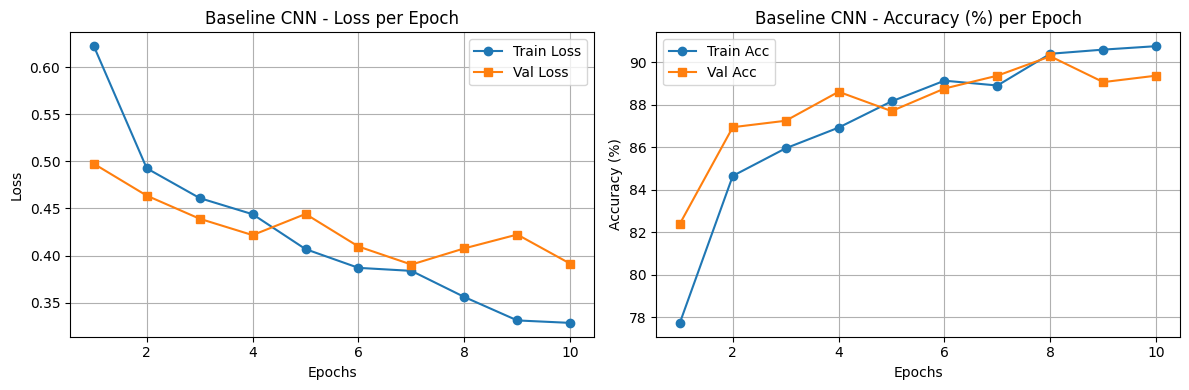

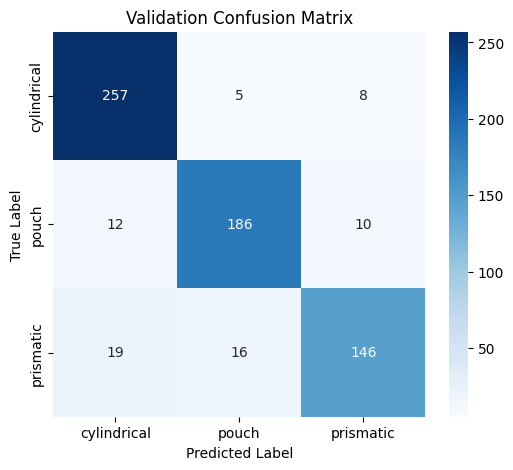


--- Classification Report ---
              precision    recall  f1-score   support

 cylindrical       0.89      0.95      0.92       270
       pouch       0.90      0.89      0.90       208
   prismatic       0.89      0.81      0.85       181

    accuracy                           0.89       659
   macro avg       0.89      0.88      0.89       659
weighted avg       0.89      0.89      0.89       659



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def plot_training_curves(history, title="Baseline CNN"):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(12, 4))

    # Plot Loss Curve
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label='Train Loss', marker='o')
    plt.plot(epochs, history['val_loss'], label='Val Loss', marker='s')
    plt.title(f'{title} - Loss per Epoch')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()

    # Plot Accuracy Curve
    plt.subplot(1, 2, 2)
    plt.plot(epochs, [acc * 100 for acc in history['train_acc']], label='Train Acc', marker='o')
    plt.plot(epochs, [acc * 100 for acc in history['val_acc']], label='Val Acc', marker='s')
    plt.title(f'{title} - Accuracy (%) per Epoch')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

def evaluate_model_performance(model, dataloader, class_names=['cylindrical', 'pouch', 'prismatic']):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    # Compute confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Plot confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Validation Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    # Print classification report
    print("\n--- Classification Report ---")
    print(classification_report(all_labels, all_preds, target_names=class_names))

plot_training_curves(baseline_history, title="Baseline CNN")
evaluate_model_performance(model_baseline, val_loader)

Increasing number of filters in each layer (16 channels and 32 channels):

In [ ]:
class HighCapacityCNN(nn.Module):
    def __init__(self, num_classes=3):
        super(HighCapacityCNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(32 * 64 * 64, 64)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))

        x = x.view(x.size(0), -1)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

model_task2 = HighCapacityCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_task2.parameters(), lr=0.001)

print(f"Total trainable parameters: {count_parameters(model_task2):,}")

task2_history = train_model(model_task2, train_loader, val_loader, criterion, optimizer, epochs=10)

Total trainable parameters: 8,393,667
Epoch [1/10] | Train Loss: 0.6719 | Train Acc: 75.52% | Val Loss: 0.5020 | Val Acc: 85.43%
Epoch [2/10] | Train Loss: 0.4715 | Train Acc: 86.31% | Val Loss: 0.4197 | Val Acc: 88.32%
Epoch [3/10] | Train Loss: 0.4319 | Train Acc: 88.49% | Val Loss: 0.4014 | Val Acc: 89.23%
Epoch [4/10] | Train Loss: 0.4073 | Train Acc: 88.26% | Val Loss: 0.4248 | Val Acc: 88.47%
Epoch [5/10] | Train Loss: 0.3898 | Train Acc: 89.01% | Val Loss: 0.3988 | Val Acc: 88.62%
Epoch [6/10] | Train Loss: 0.3648 | Train Acc: 89.47% | Val Loss: 0.4219 | Val Acc: 89.53%
Epoch [7/10] | Train Loss: 0.3512 | Train Acc: 90.08% | Val Loss: 0.4293 | Val Acc: 87.41%
Epoch [8/10] | Train Loss: 0.3341 | Train Acc: 90.34% | Val Loss: 0.3935 | Val Acc: 89.38%
Epoch [9/10] | Train Loss: 0.3070 | Train Acc: 91.25% | Val Loss: 0.4312 | Val Acc: 89.83%
Epoch [10/10] | Train Loss: 0.2842 | Train Acc: 91.71% | Val Loss: 0.4098 | Val Acc: 89.98%


Visualization:


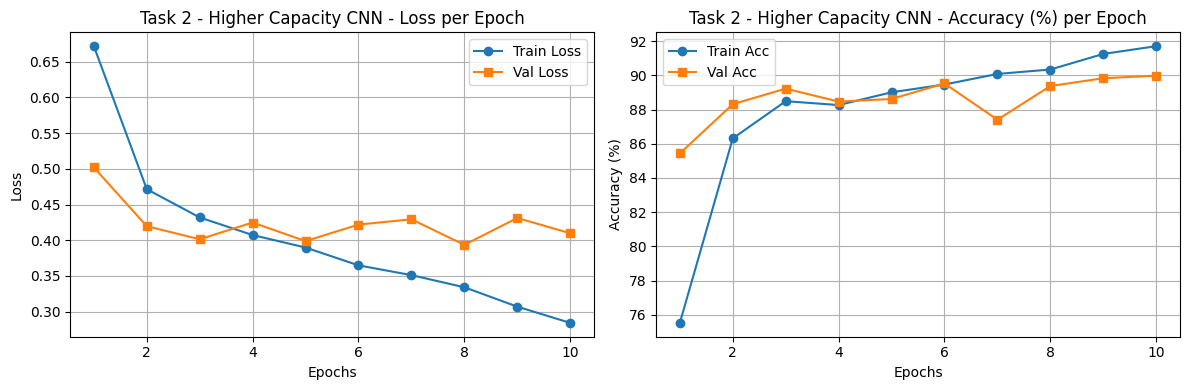

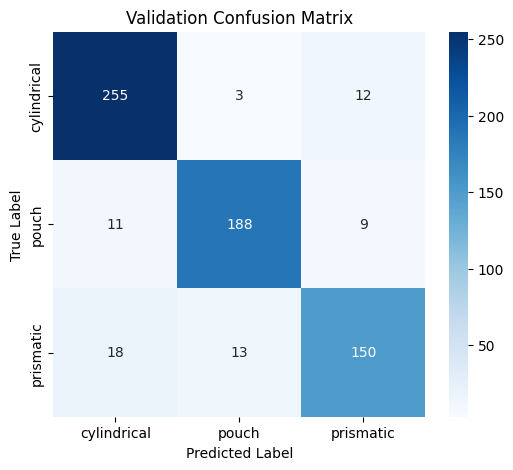


--- Classification Report ---
              precision    recall  f1-score   support

 cylindrical       0.90      0.94      0.92       270
       pouch       0.92      0.90      0.91       208
   prismatic       0.88      0.83      0.85       181

    accuracy                           0.90       659
   macro avg       0.90      0.89      0.90       659
weighted avg       0.90      0.90      0.90       659



In [ ]:
plot_training_curves(task2_history, title="Task 2 - Higher Capacity CNN")
evaluate_model_performance(model_task2, val_loader)

Deeper CNN (4 conv):

In [ ]:

class DeeperCNN(nn.Module):
    def __init__(self, num_classes=3):
        super(DeeperCNN, self).__init__()

        # Conv Block 1: 1 -> 16
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)  # Output: (16, 128, 128)

        # Conv Block 2: 16 -> 32
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)  # Output: (32, 64, 64)

        # Conv Block 3: 32 -> 64
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2, 2)  # Output: (64, 32, 32)

        # Conv Block 4: 64 -> 128
        self.conv4 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.relu4 = nn.ReLU()
        self.pool4 = nn.MaxPool2d(2, 2)  # Output: (128, 16, 16)

        self.fc1 = nn.Linear(128 * 16 * 16, 64)
        self.relu5 = nn.ReLU()
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        x = self.pool4(self.relu4(self.conv4(x)))

        x = x.view(x.size(0), -1)
        x = self.relu5(self.fc1(x))
        x = self.fc2(x)
        return x

model_task3 = DeeperCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_task3.parameters(), lr=0.001)

print(f"Total trainable parameters: {count_parameters(model_task3):,}")

task3_history = train_model(model_task3, train_loader, val_loader, criterion, optimizer, epochs=10)

Total trainable parameters: 2,194,563
Epoch [1/10] | Train Loss: 0.6738 | Train Acc: 72.63% | Val Loss: 0.5156 | Val Acc: 84.67%
Epoch [2/10] | Train Loss: 0.5031 | Train Acc: 84.82% | Val Loss: 0.4926 | Val Acc: 85.74%
Epoch [3/10] | Train Loss: 0.4660 | Train Acc: 85.86% | Val Loss: 0.4507 | Val Acc: 87.56%
Epoch [4/10] | Train Loss: 0.4430 | Train Acc: 87.00% | Val Loss: 0.4402 | Val Acc: 86.80%
Epoch [5/10] | Train Loss: 0.4291 | Train Acc: 88.36% | Val Loss: 0.4213 | Val Acc: 87.86%
Epoch [6/10] | Train Loss: 0.4021 | Train Acc: 88.17% | Val Loss: 0.4047 | Val Acc: 89.53%
Epoch [7/10] | Train Loss: 0.3819 | Train Acc: 89.34% | Val Loss: 0.3805 | Val Acc: 90.29%
Epoch [8/10] | Train Loss: 0.3667 | Train Acc: 89.60% | Val Loss: 0.3807 | Val Acc: 89.98%
Epoch [9/10] | Train Loss: 0.3633 | Train Acc: 90.15% | Val Loss: 0.3877 | Val Acc: 90.14%
Epoch [10/10] | Train Loss: 0.3437 | Train Acc: 90.47% | Val Loss: 0.4266 | Val Acc: 89.07%


Visualization

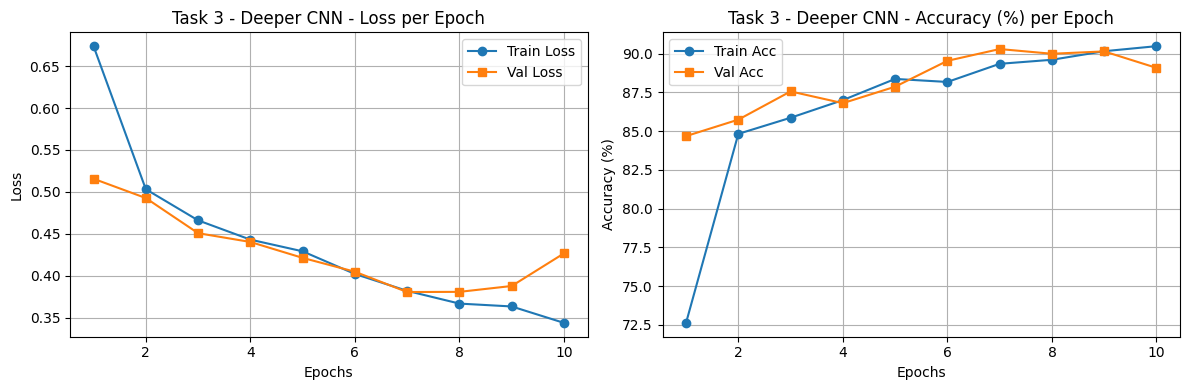

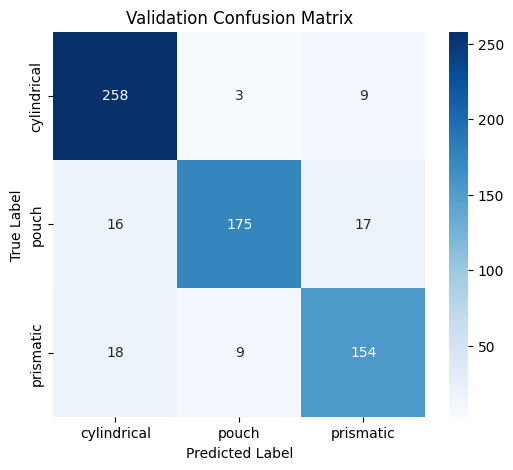


--- Classification Report ---
              precision    recall  f1-score   support

 cylindrical       0.88      0.96      0.92       270
       pouch       0.94      0.84      0.89       208
   prismatic       0.86      0.85      0.85       181

    accuracy                           0.89       659
   macro avg       0.89      0.88      0.89       659
weighted avg       0.89      0.89      0.89       659



In [ ]:
plot_training_curves(task3_history, title="Task 3 - Deeper CNN")
evaluate_model_performance(model_task3, val_loader)

Batch Normalization:

In [ ]:
class BatchNormCNN(nn.Module):
    def __init__(self, num_classes=3):
        super(BatchNormCNN, self).__init__()

        # Conv Block 1: Conv -> BN -> ReLU -> Pool
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16) # Batch Normalization
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)

        # Conv Block 2: Conv -> BN -> ReLU -> Pool
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)

        # Conv Block 3: Conv -> BN -> ReLU -> Pool
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2, 2)

        # Conv Block 4: Conv -> BN -> ReLU -> Pool
        self.conv4 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(128)
        self.relu4 = nn.ReLU()
        self.pool4 = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(128 * 16 * 16, 64)
        self.relu5 = nn.ReLU()
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu3(self.bn3(self.conv3(x))))
        x = self.pool4(self.relu4(self.bn4(self.conv4(x))))

        x = x.view(x.size(0), -1)
        x = self.relu5(self.fc1(x))
        x = self.fc2(x)
        return x
model_task4 = BatchNormCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_task4.parameters(), lr=0.001)

print(f"Total trainable parameters: {count_parameters(model_task4):,}")

task4_history = train_model(model_task4, train_loader, val_loader, criterion, optimizer, epochs=10)

Total trainable parameters: 2,195,043
Epoch [1/10] | Train Loss: 1.0378 | Train Acc: 72.92% | Val Loss: 0.6185 | Val Acc: 80.73%
Epoch [2/10] | Train Loss: 0.6006 | Train Acc: 82.12% | Val Loss: 0.5757 | Val Acc: 80.27%
Epoch [3/10] | Train Loss: 0.5334 | Train Acc: 83.55% | Val Loss: 0.4828 | Val Acc: 84.37%
Epoch [4/10] | Train Loss: 0.4755 | Train Acc: 86.54% | Val Loss: 0.4691 | Val Acc: 87.25%
Epoch [5/10] | Train Loss: 0.4391 | Train Acc: 86.64% | Val Loss: 0.4299 | Val Acc: 87.71%
Epoch [6/10] | Train Loss: 0.4201 | Train Acc: 87.94% | Val Loss: 0.4192 | Val Acc: 88.01%
Epoch [7/10] | Train Loss: 0.4060 | Train Acc: 87.91% | Val Loss: 0.4306 | Val Acc: 88.47%
Epoch [8/10] | Train Loss: 0.3992 | Train Acc: 88.49% | Val Loss: 0.4143 | Val Acc: 89.38%
Epoch [9/10] | Train Loss: 0.3816 | Train Acc: 89.56% | Val Loss: 0.4322 | Val Acc: 88.92%
Epoch [10/10] | Train Loss: 0.3791 | Train Acc: 88.95% | Val Loss: 0.3782 | Val Acc: 89.68%


Visualization

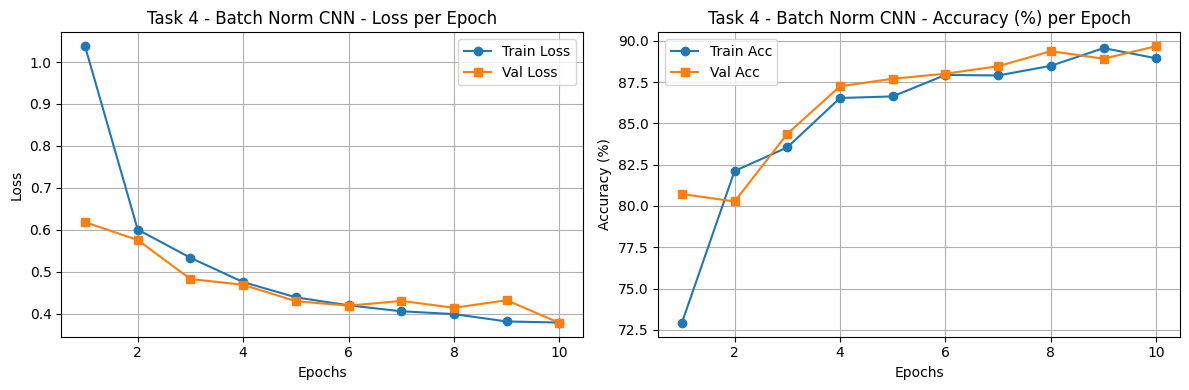

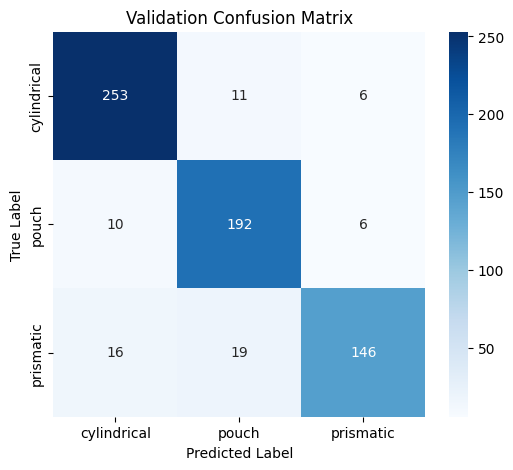


--- Classification Report ---
              precision    recall  f1-score   support

 cylindrical       0.91      0.94      0.92       270
       pouch       0.86      0.92      0.89       208
   prismatic       0.92      0.81      0.86       181

    accuracy                           0.90       659
   macro avg       0.90      0.89      0.89       659
weighted avg       0.90      0.90      0.90       659



In [ ]:
plot_training_curves(task4_history, title="Task 4 - Batch Norm CNN")
evaluate_model_performance(model_task4, val_loader)

Changing Kernel Sizes:

In [ ]:
class KernelSizeCNN(nn.Module):
    def __init__(self, num_classes=3):
        super(KernelSizeCNN, self).__init__()

        # Conv Block 1: Kernel 5x5, Padding 2
        self.conv1 = nn.Conv2d(1, 16, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm2d(16)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)

        # Conv Block 2: Kernel 5x5, Padding 2
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm2d(32)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)

        # Conv Block 3: Kernel 5x5, Padding 2
        self.conv3 = nn.Conv2d(32, 64, kernel_size=5, padding=2)
        self.bn3 = nn.BatchNorm2d(64)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2, 2)

        # Conv Block 4: Kernel 5x5, Padding 2
        self.conv4 = nn.Conv2d(64, 128, kernel_size=5, padding=2)
        self.bn4 = nn.BatchNorm2d(128)
        self.relu4 = nn.ReLU()
        self.pool4 = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(128 * 16 * 16, 64)
        self.relu5 = nn.ReLU()
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu3(self.bn3(self.conv3(x))))
        x = self.pool4(self.relu4(self.bn4(self.conv4(x))))

        x = x.view(x.size(0), -1)
        x = self.relu5(self.fc1(x))
        x = self.fc2(x)
        return x

model_task5 = KernelSizeCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_task5.parameters(), lr=0.001)

print(f"Total trainable parameters: {count_parameters(model_task5):,}")

task5_history = train_model(model_task5, train_loader, val_loader, criterion, optimizer, epochs=10)

Total trainable parameters: 2,367,331
Epoch [1/10] | Train Loss: 1.2145 | Train Acc: 68.21% | Val Loss: 0.9354 | Val Acc: 79.97%
Epoch [2/10] | Train Loss: 0.7525 | Train Acc: 80.85% | Val Loss: 0.7774 | Val Acc: 83.61%
Epoch [3/10] | Train Loss: 0.6126 | Train Acc: 83.03% | Val Loss: 0.5904 | Val Acc: 83.76%
Epoch [4/10] | Train Loss: 0.4916 | Train Acc: 84.59% | Val Loss: 0.4696 | Val Acc: 84.52%
Epoch [5/10] | Train Loss: 0.4771 | Train Acc: 85.66% | Val Loss: 0.4711 | Val Acc: 87.41%
Epoch [6/10] | Train Loss: 0.4481 | Train Acc: 86.51% | Val Loss: 0.4260 | Val Acc: 88.01%
Epoch [7/10] | Train Loss: 0.4197 | Train Acc: 87.97% | Val Loss: 0.4223 | Val Acc: 86.19%
Epoch [8/10] | Train Loss: 0.4092 | Train Acc: 88.30% | Val Loss: 0.4257 | Val Acc: 89.68%
Epoch [9/10] | Train Loss: 0.4114 | Train Acc: 88.72% | Val Loss: 0.4460 | Val Acc: 88.77%
Epoch [10/10] | Train Loss: 0.3882 | Train Acc: 89.11% | Val Loss: 0.4285 | Val Acc: 89.23%


Visualization

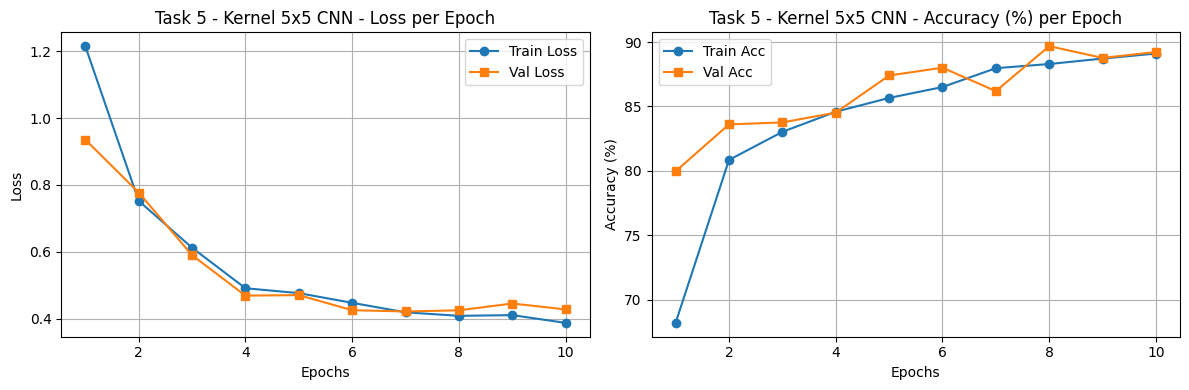

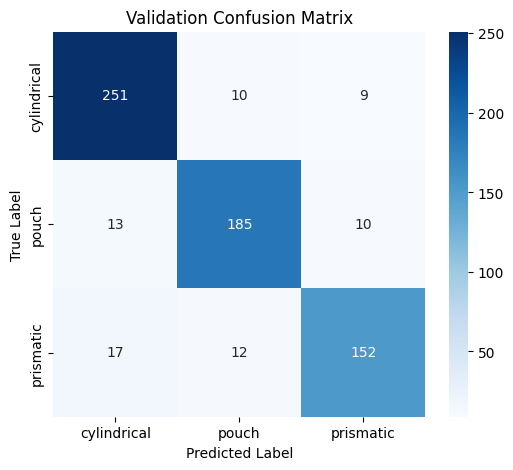


--- Classification Report ---
              precision    recall  f1-score   support

 cylindrical       0.89      0.93      0.91       270
       pouch       0.89      0.89      0.89       208
   prismatic       0.89      0.84      0.86       181

    accuracy                           0.89       659
   macro avg       0.89      0.89      0.89       659
weighted avg       0.89      0.89      0.89       659



In [ ]:
plot_training_curves(task5_history, title="Task 5 - Kernel 5x5 CNN")
evaluate_model_performance(model_task5, val_loader)

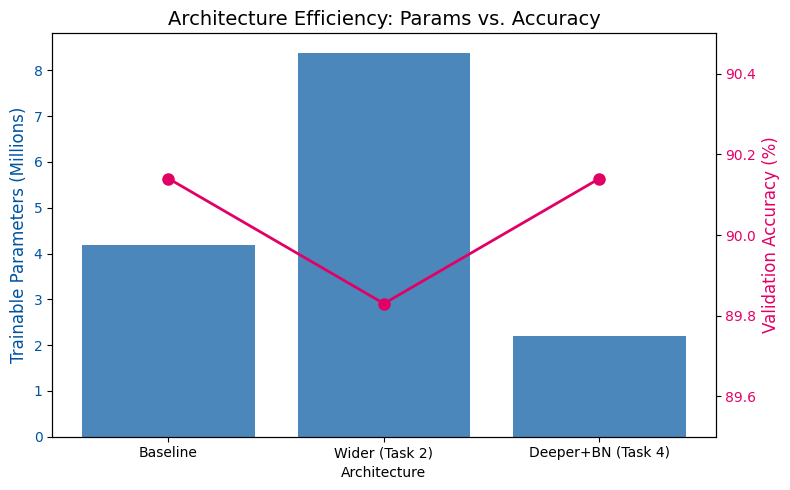

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Dados baseados nos seus resultados das Tasks 1, 2 e 4
models = ['Baseline', 'Wider (Task 2)', 'Deeper+BN (Task 4)']
params = [4.19, 8.39, 2.19]  # Em Milhões
accuracy = [90.14, 89.83, 90.14]

fig, ax1 = plt.subplots(figsize=(8, 5))

# Eixo 1: Parâmetros (Barras)
color = '#00549F' # RWTH Blue (conforme o estilo da sua apresentação)
ax1.set_xlabel('Architecture')
ax1.set_ylabel('Trainable Parameters (Millions)', color=color, fontsize=12)
ax1.bar(models, params, color=color, alpha=0.7, label='Params (M)')
ax1.tick_params(axis='y', labelcolor=color)

# Eixo 2: Acurácia (Linha com marcadores)
ax2 = ax1.twinx()
color = '#E30066' # RWTH Magenta (usar cores do seu guia de estilo)
ax2.set_ylabel('Validation Accuracy (%)', color=color, fontsize=12)
ax2.plot(models, accuracy, color=color, marker='o', linewidth=2, markersize=8, label='Accuracy')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(89.5, 90.5) # Ajuste para dar foco na variação

plt.title('Architecture Efficiency: Params vs. Accuracy', fontsize=14)
fig.tight_layout()
plt.show()